In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

csv_file_path_post = "/content/drive/MyDrive/Data Sci CU/Big Data Computation/Project/Sampling_Post_for_EDA.csv"
csv_file_path_comment = "/content/drive/MyDrive/Data Sci CU/Big Data Computation/Project/Sampling_Comment_for_EDA.csv"

Mounted at /content/drive


# Key Massage

Post
1. content_categories กับ View Count เป็น Missing เกือบหมด
2. ค่า Down Vote ไม่น่าใช้ มีค่า 0 เยอะเกินไป
3. ChatGPT ยังคงเป็น Main Stream LLM เพราะมีคนพูดถึงเกิน 50% รองลงมาคือ Claudes (น่าสนใจว่ามันเยอะกว่า Gemini มาก อาจ Imply ได้ว่า Claudes ส่งผลกระทบต่อ Gemini มากกว่า OpenAI แต่ต้องสำรวจ Trend ดีๆ)
4. เกือบ 25% ของ Post ทั้งหมดมีตัวอักษรไม่เกิน 25 ตัว คำถามสั้นๆ พวกนี้อาจต้องเอาออกเพราะหลายๆ อันจับบริบทยาก (?)  

Comment
1. หลาย Comment มักเป็นอะไรสั้นๆ ทำให้จับ Sentiment ได้ยากเกินไป และค่อนข้าง Trash

Trend
1. ทั้ง Post และ Comment มีแนวโน้มใกล้ๆ กัน (อยู่แล้ว) คือช่วงปี 2025 แนวโน้มการพูดถึงเพิ่มขึ้นช้าๆ มีลงบ้าง แต่หลังปี 2026 การพูดถึงมีเยอะขึ้นอย่างรวดเร็ว

In [ ]:
post = pd.read_csv(csv_file_path_post)
comment = pd.read_csv(csv_file_path_comment)

print(post.head())
print(comment.head())

   content_categories  created_utc  \
0                 NaN   1765125544   
1                 NaN   1765151626   
2                 NaN   1765152092   
3                 NaN   1765179694   
4                 NaN   1765185884   

                                            selftext subreddit  \
0  I’m curious to know how others use or engage w...   ChatGPT   
1                                                NaN   ChatGPT   
2  [https://chatgpt.com/share/69361514-15f0-800b-...   ChatGPT   
3                                          [removed]   ChatGPT   
4                                          [removed]   ChatGPT   

                                               title  upvote_ratio  ups  \
0              What do you talk about with Chat GPT?          0.43    0   
1  The year is 2033. The robots do the work, but ...          0.67    1   
2        ChatGPT Respelled Half the Word in Cyrillic          0.50    0   
3                  The AI cold war has already begun          1.00    1   

# Numeric EDA

## Statistics

In [ ]:
# Basic Statistic
numeric_post_col = ['upvote_ratio', 'ups', 'downs', 'view_count']
numeric_comment_col = ['score', 'ups']

print(post[numeric_post_col].describe())
print(comment[numeric_comment_col].describe())

       upvote_ratio           ups    downs  view_count
count  10107.000000  10107.000000  10107.0         0.0
mean       0.786162     41.141486      0.0         NaN
std        0.246784    438.644387      0.0         NaN
min        0.040000      0.000000      0.0         NaN
25%        0.600000      1.000000      0.0         NaN
50%        0.890000      1.000000      0.0         NaN
75%        1.000000      3.000000      0.0         NaN
max        1.000000  16425.000000      0.0         NaN
              score           ups
count  10125.000000  10125.000000
mean       5.381235      5.381235
std       42.404282     42.404282
min      -99.000000    -99.000000
25%        1.000000      1.000000
50%        1.000000      1.000000
75%        2.000000      2.000000
max     2141.000000   2141.000000


## Univariate Visualize

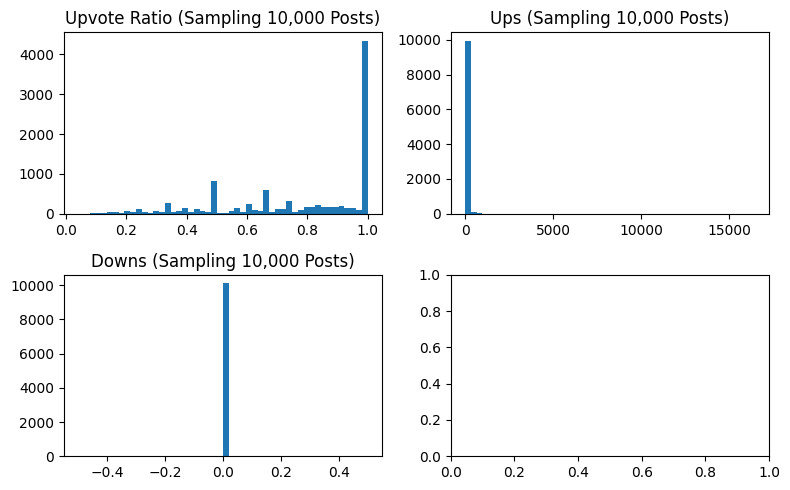

In [ ]:
# Post - Histogram
fig, axes = plt.subplots(2,2,figsize=(8, 5))

axes[0,0].hist(post['upvote_ratio'],bins = 50)
axes[0,0].set_title('Upvote Ratio (Sampling 10,000 Posts)')

axes[0,1].hist(post['ups'],bins = 50)
axes[0,1].set_title('Ups (Sampling 10,000 Posts)')

axes[1,0].hist(post['downs'], bins = 50)
axes[1,0].set_title('Downs (Sampling 10,000 Posts)')

# axes[1,1].hist(post['view_count'])
# axes[1,1].set_title('View Count (Sampling 10,000 Posts)')

plt.tight_layout()
plt.show()

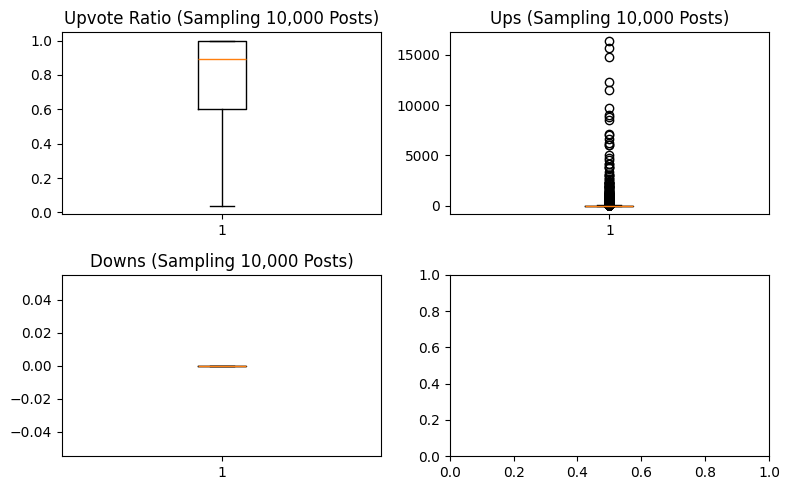

In [ ]:
# Post - Histogram
fig, axes = plt.subplots(2,2,figsize=(8, 5))

axes[0,0].boxplot(post['upvote_ratio'])
axes[0,0].set_title('Upvote Ratio (Sampling 10,000 Posts)')

axes[0,1].boxplot(post['ups'])
axes[0,1].set_title('Ups (Sampling 10,000 Posts)')

axes[1,0].boxplot(post['downs'])
axes[1,0].set_title('Downs (Sampling 10,000 Posts)')

# axes[1,1].hist(post['view_count'])
# axes[1,1].set_title('View Count (Sampling 10,000 Posts)')

plt.tight_layout()
plt.show()

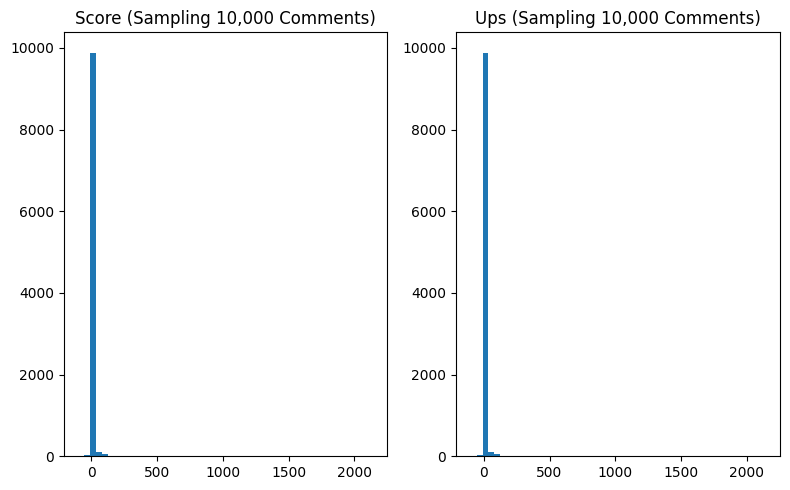

In [ ]:
# Comment - Histogram
fig, axes = plt.subplots(1,2,figsize=(8, 5))

axes[0].hist(comment['score'], bins = 50)
axes[0].set_title('Score (Sampling 10,000 Comments)')

axes[1].hist(comment['ups'], bins = 50)
axes[1].set_title('Ups (Sampling 10,000 Comments)')

plt.tight_layout()
plt.show()

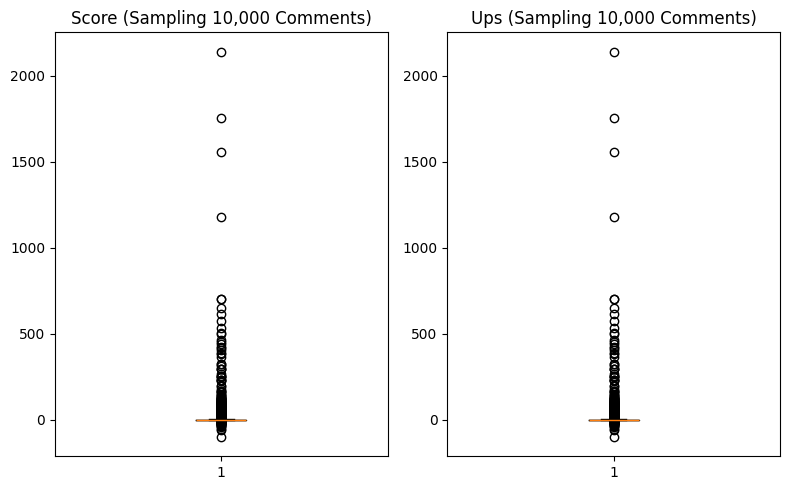

In [ ]:
# Comment - Histogram
fig, axes = plt.subplots(1,2,figsize=(8, 5))

axes[0].boxplot(comment['score'])
axes[0].set_title('Score (Sampling 10,000 Comments)')

axes[1].boxplot(comment['ups'])
axes[1].set_title('Ups (Sampling 10,000 Comments)')

plt.tight_layout()
plt.show()

# Categorical EDA

In [ ]:
# Post
print('content_categories')
print(post['content_categories'].value_counts(dropna=False))

print('subreddit')
print(post['subreddit'].value_counts(dropna=False))

content_categories
content_categories
NaN    10107
Name: count, dtype: int64
subreddit
subreddit
ChatGPT       4678
OpenAI        1392
ClaudeAI      1232
grok           955
GeminiAI       675
Bard           453
ChatGPTPro     300
DeepSeek       273
Anthropic      149
Name: count, dtype: int64


In [ ]:
# Comment
print('is_submitter')
print(comment['is_submitter'].value_counts(dropna=False))

print('removal_reason')
print(comment['removal_reason'].value_counts(dropna=False))

print('subreddit')
print(comment['subreddit'].value_counts(dropna=False))

is_submitter
is_submitter
False    9310
True      815
Name: count, dtype: int64
removal_reason
removal_reason
NaN      10124
legal        1
Name: count, dtype: int64
subreddit
subreddit
ChatGPT       5735
OpenAI        1617
ClaudeAI      1037
grok           602
GeminiAI       350
Bard           299
ChatGPTPro     244
DeepSeek       133
Anthropic      108
Name: count, dtype: int64


# String EDA

In [ ]:
post['title_character'] = post['title'].apply(lambda x: len(str(x)))
comment['title_character'] = comment['body'].apply(lambda x: len(str(x)))

In [ ]:
print(post['title_character'].describe())
print(comment['title_character'].describe())

count    10107.000000
mean        53.711190
std         39.972101
min          1.000000
25%         26.000000
50%         45.000000
75%         69.000000
max        300.000000
Name: title_character, dtype: float64
count    10125.000000
mean       196.097185
std        291.666763
min          1.000000
25%         38.000000
50%        101.000000
75%        220.000000
max       4726.000000
Name: title_character, dtype: float64


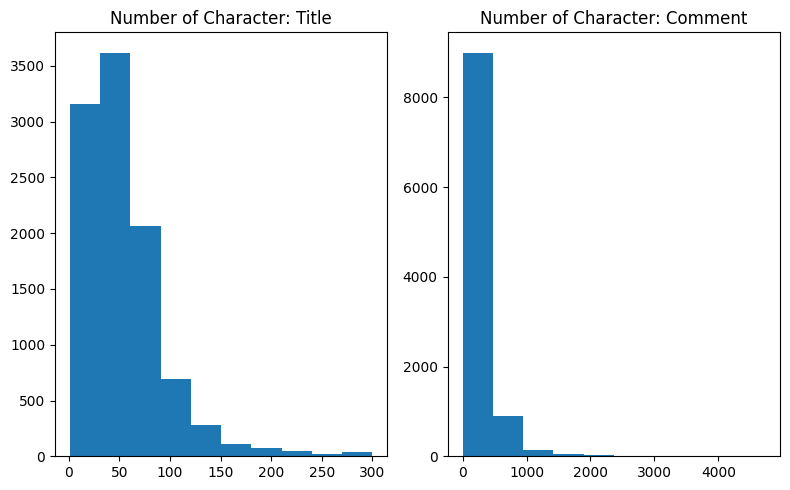

In [ ]:
# Histogram
fig, axes = plt.subplots(1,2,figsize=(8, 5))

axes[0].hist(post['title_character'])
axes[0].set_title('Number of Character: Title')

axes[1].hist(comment['title_character'])
axes[1].set_title('Number of Character: Comment')

plt.tight_layout()
plt.show()

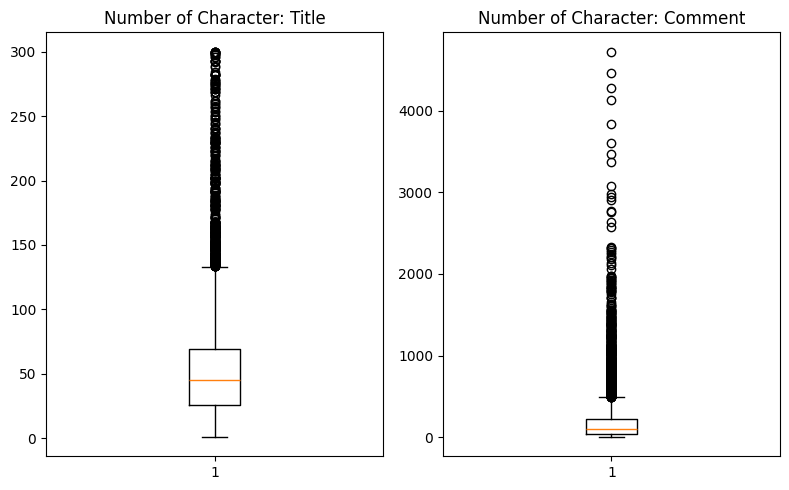

In [ ]:
# Box Plot
fig, axes = plt.subplots(1,2,figsize=(8, 5))

axes[0].boxplot(post['title_character'])
axes[0].set_title('Number of Character: Title')

axes[1].boxplot(comment['title_character'])
axes[1].set_title('Number of Character: Comment')

plt.tight_layout()
plt.show()

In [47]:
post_less_character = post[post['title_character'] <= 26]

display(post_less_character)

,content_categories,created_utc,selftext,subreddit,title,upvote_ratio,ups,downs,view_count,title_character,date_time,month,analysis_year,regrouped_subreddit,year,date_key
4,NaN,1765185884,[removed],ChatGPT,Best Rizz GPT?,1.00,1,0,NaN,14,2025-12-08 09:24:44,12,2025,ChatGPT,2025,2025-12
8,NaN,1765218839,Não aguento mais usar o Chat GPT no Windows.\n...,ChatGPT,IMPOSSÍVEL USAR NO WINDOWS,0.67,2,0,NaN,26,2025-12-08 18:33:59,12,2025,ChatGPT,2025,2025-12
16,NaN,1765378001,Something weird I've noticed is that ChatGPT o...,ChatGPT,Another emoji issue,0.67,1,0,NaN,19,2025-12-10 14:46:41,12,2025,ChatGPT,2025,2025-12
21,NaN,1765477881,NaN,ChatGPT,𝓕𝓻𝓮𝓪𝓴𝔂 GPT,0.60,1,0,NaN,10,2025-12-11 18:31:21,12,2025,ChatGPT,2025,2025-12
27,NaN,1765530253,GPT 5.2 is planing and working sistematicaly !...,ChatGPT,GPT-5.2 is good for coding,0.29,0,0,NaN,26,2025-12-12 09:04:13,12,2025,ChatGPT,2025,2025-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10094,NaN,1766631543,[removed],Anthropic,Thanks!,1.00,1,0,NaN,7,2025-12-25 02:59:03,12,2025,ClaudeAI,2025,2025-12
10097,NaN,1769495490,# Glass AI — ChatGPT Doesn’t Deserve to Look T...,ChatGPTPro,Glass AI,0.27,0,0,NaN,8,2026-01-27 06:31:30,1,2026,ChatGPT,2026,2026-01
10100,NaN,1770518617,Hi there! I’ve heard good things about 4.5 and...,ChatGPTPro,Wanting to switch to Pro,0.61,5,0,NaN,24,2026-02-08 02:43:37,2,2026,ChatGPT,2026,2026-02
10101,NaN,1770622394,Codex App Skills blew me away.\n\nI built a Po...,ChatGPTPro,Codex Skills,0.84,12,0,NaN,12,2026-02-09 07:33:14,2,2026,ChatGPT,2026,2026-02


In [48]:
post_mediantolarge_character = post[post['title_character'] >= 45]

display(post_mediantolarge_character)

,content_categories,created_utc,selftext,subreddit,title,upvote_ratio,ups,downs,view_count,title_character,date_time,month,analysis_year,regrouped_subreddit,year,date_key
1,NaN,1765151626,NaN,ChatGPT,"The year is 2033. The robots do the work, but ...",0.67,1,0,NaN,78,2025-12-07 23:53:46,12,2025,ChatGPT,2025,2025-12
5,NaN,1765197324,TL;DR\n\n**1. new landscape of open source: Ch...,ChatGPT,Key Insights from OpenRouter's 2025 State of A...,1.00,6,0,NaN,54,2025-12-08 12:35:24,12,2025,ChatGPT,2025,2025-12
6,NaN,1765203194,[removed],ChatGPT,"A buddy comedy featuring ChatGPT, Grok, Claude...",1.00,1,0,NaN,54,2025-12-08 14:13:14,12,2025,ChatGPT,2025,2025-12
10,NaN,1765272994,NaN,ChatGPT,ChatGPT is so good - it not only snapped the w...,0.31,0,0,NaN,115,2025-12-09 09:36:34,12,2025,ChatGPT,2025,2025-12
11,NaN,1765301161,Not talking about the usual “it guessed my fav...,ChatGPT,Has ChatGPT ever known something about you tha...,1.00,1,0,NaN,83,2025-12-09 17:26:01,12,2025,ChatGPT,2025,2025-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10098,NaN,1769848910,"I was working heavily with just pro model(s), ...",ChatGPTPro,Love Codex. Any techniques to use it plus ultra?,0.86,5,0,NaN,48,2026-01-31 08:41:50,1,2026,ChatGPT,2026,2026-01
10099,NaN,1769941949,[removed],ChatGPTPro,"I gave up waiting for bugs to show up. The ""Ch...",1.00,1,0,NaN,139,2026-02-01 10:32:29,2,2026,ChatGPT,2026,2026-02
10102,NaN,1771277798,Is it worth paying for a really expensive opti...,ChatGPTPro,Just delivered the best pitch of my life and g...,1.00,1,0,NaN,283,2026-02-16 21:36:38,2,2026,ChatGPT,2026,2026-02
10104,NaN,1771442837,Obviously not talking about using the API in t...,ChatGPTPro,Has anyone compared using the API vs. dedicate...,0.85,9,0,NaN,85,2026-02-18 19:27:17,2,2026,ChatGPT,2026,2026-02


## DateTime

In [ ]:
post['date_time'] = pd.to_datetime(post['created_utc'], unit='s')
comment['date_time'] = pd.to_datetime(comment['created_utc'], unit='s')

In [ ]:
post

,content_categories,created_utc,selftext,subreddit,title,upvote_ratio,ups,downs,view_count,title_character,date_time
0,NaN,1765125544,I’m curious to know how others use or engage w...,ChatGPT,What do you talk about with Chat GPT?,0.43,0,0,NaN,37,2025-12-07 16:39:04
1,NaN,1765151626,NaN,ChatGPT,"The year is 2033. The robots do the work, but ...",0.67,1,0,NaN,78,2025-12-07 23:53:46
2,NaN,1765152092,[https://chatgpt.com/share/69361514-15f0-800b-...,ChatGPT,ChatGPT Respelled Half the Word in Cyrillic,0.50,0,0,NaN,43,2025-12-08 00:01:32
3,NaN,1765179694,[removed],ChatGPT,The AI cold war has already begun,1.00,1,0,NaN,33,2025-12-08 07:41:34
4,NaN,1765185884,[removed],ChatGPT,Best Rizz GPT?,1.00,1,0,NaN,14,2025-12-08 09:24:44
...,...,...,...,...,...,...,...,...,...,...,...
10102,NaN,1771277798,Is it worth paying for a really expensive opti...,ChatGPTPro,Just delivered the best pitch of my life and g...,1.00,1,0,NaN,283,2026-02-16 21:36:38
10103,NaN,1771358849,Make your GPT write like human\n\nGuys it seem...,ChatGPTPro,Make your GPT to talk with you like human,0.50,0,0,NaN,41,2026-02-17 20:07:29
10104,NaN,1771442837,Obviously not talking about using the API in t...,ChatGPTPro,Has anyone compared using the API vs. dedicate...,0.85,9,0,NaN,85,2026-02-18 19:27:17
10105,NaN,1772189641,"Because fuck them, that is why.\n\nBend the kn...",Anthropic,Do you know why Anthropic now shows down time ...,0.33,0,0,NaN,71,2026-02-27 10:54:01


In [ ]:
# Create Month-Year
post['month'] = post['date_time'].dt.month
post['year'] = post['date_time'].dt.year

comment['month'] = comment['date_time'].dt.month
comment['year'] = comment['date_time'].dt.year

# Apply custom year logic
def custom_year(row):
    if row['month'] in [1, 2]:
        return 2026
    else:
        return 2025

post['analysis_year'] = post.apply(custom_year, axis=1)
post['date_key'] = post['analysis_year'].astype(str) + '-' + post['month'].astype(str).str.zfill(2)

comment['analysis_year'] = comment.apply(custom_year, axis=1)
comment['date_key'] = comment['analysis_year'].astype(str) + '-' + comment['month'].astype(str).str.zfill(2)

In [ ]:
post_all_group = post.groupby('date_key').size().reset_index(name='post_count')
comment_all_group = comment.groupby('date_key').size().reset_index(name='comment_count')

print(post_all_group)
print(comment_all_group)

   date_key  post_count
0   2025-03         587
1   2025-04         814
2   2025-05         750
3   2025-06         739
4   2025-07         741
5   2025-08        1029
6   2025-09         642
7   2025-10         796
8   2025-11         705
9   2025-12         746
10  2026-01        1296
11  2026-02        1262
   date_key  comment_count
0   2025-03            579
1   2025-04            728
2   2025-05            836
3   2025-06            861
4   2025-07            778
5   2025-08           1084
6   2025-09            623
7   2025-10           1024
8   2025-11            530
9   2025-12            644
10  2026-01           1343
11  2026-02           1095


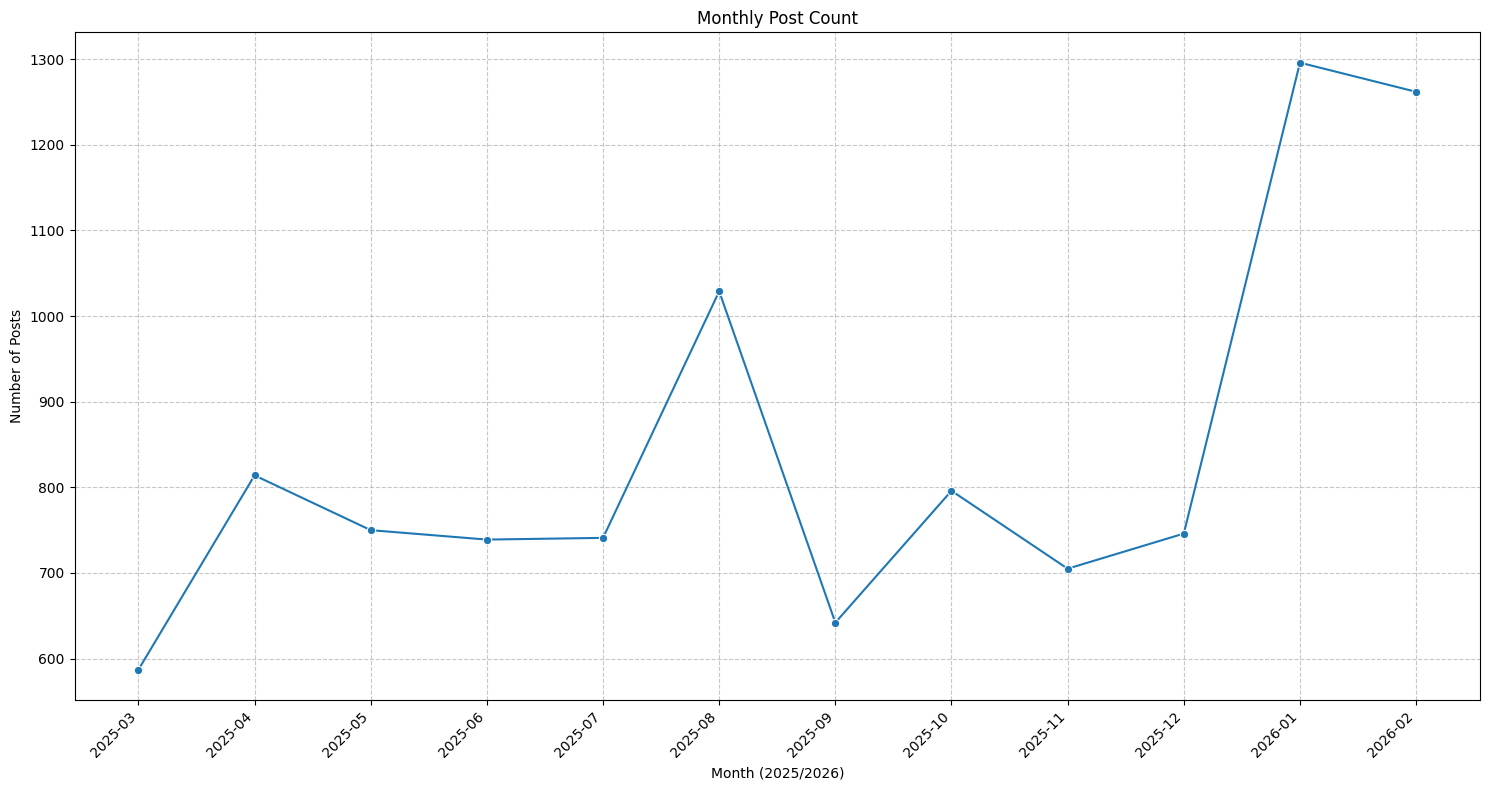

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=post_all_group, x='date_key', y='post_count', marker='o')

plt.title('Monthly Post Count')
plt.xlabel('Month (2025/2026)')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

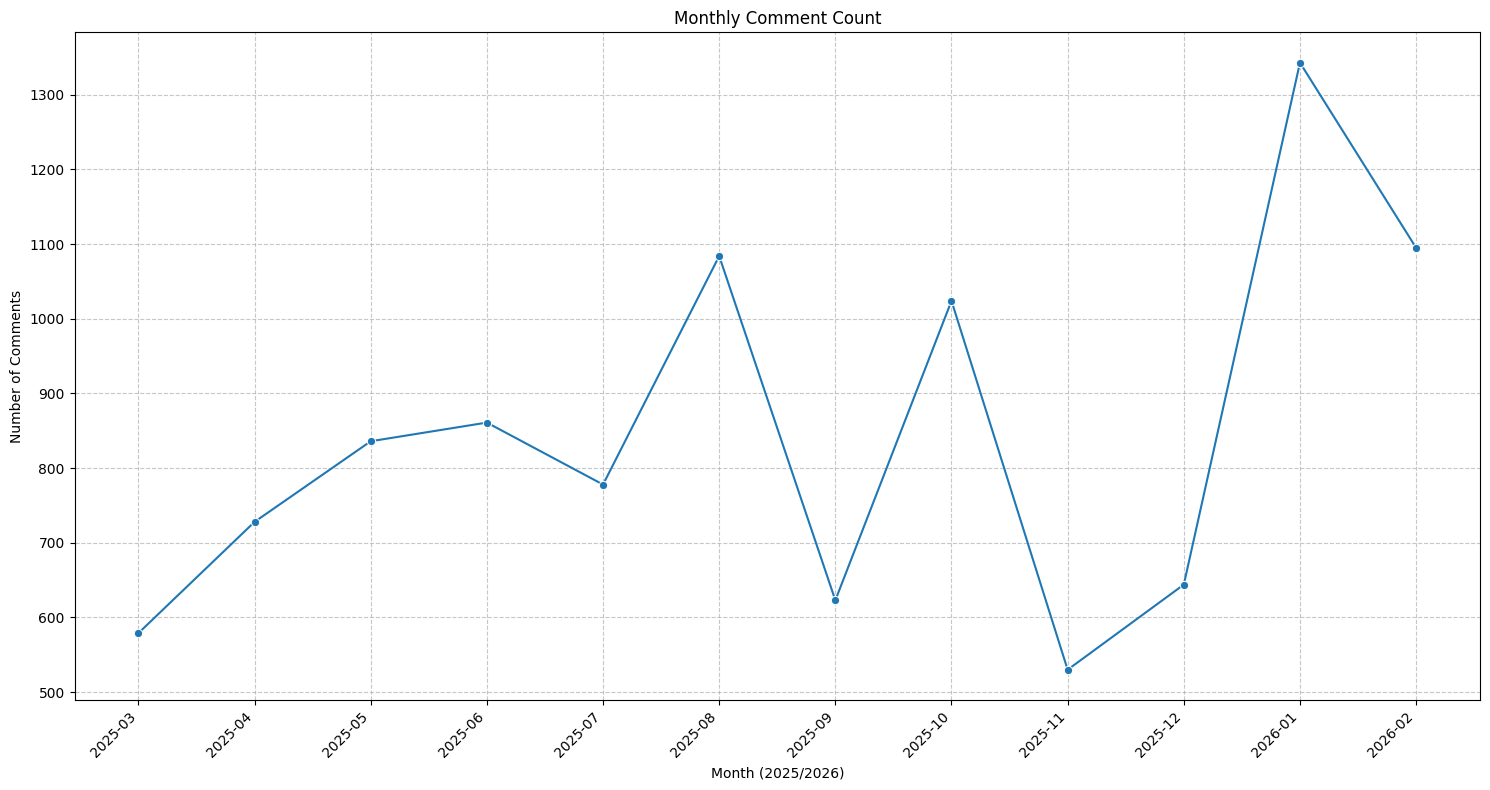

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=comment_all_group, x='date_key', y='comment_count', marker='o')

plt.title('Monthly Comment Count')
plt.xlabel('Month (2025/2026)')
plt.ylabel('Number of Comments')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Group by the custom year, month, and subreddit to count posts
monthly_subreddit_posts_custom_year = post.groupby(['analysis_year', 'month', 'date_key', 'subreddit']).size().unstack(fill_value=0)
monthly_subreddit_posts_custom_year = monthly_subreddit_posts_custom_year.reset_index()

# Melt the DataFrame to long format for easier plotting
df_melted = monthly_subreddit_posts_custom_year.melt(id_vars=['analysis_year', 'month', 'date_key'], var_name='subreddit', value_name='post_count')
display(df_melted.head())

,analysis_year,month,date_key,subreddit,post_count
0,2025,3,2025-03,Anthropic,3
1,2025,4,2025-04,Anthropic,1
2,2025,5,2025-05,Anthropic,1
3,2025,6,2025-06,Anthropic,2
4,2025,7,2025-07,Anthropic,6


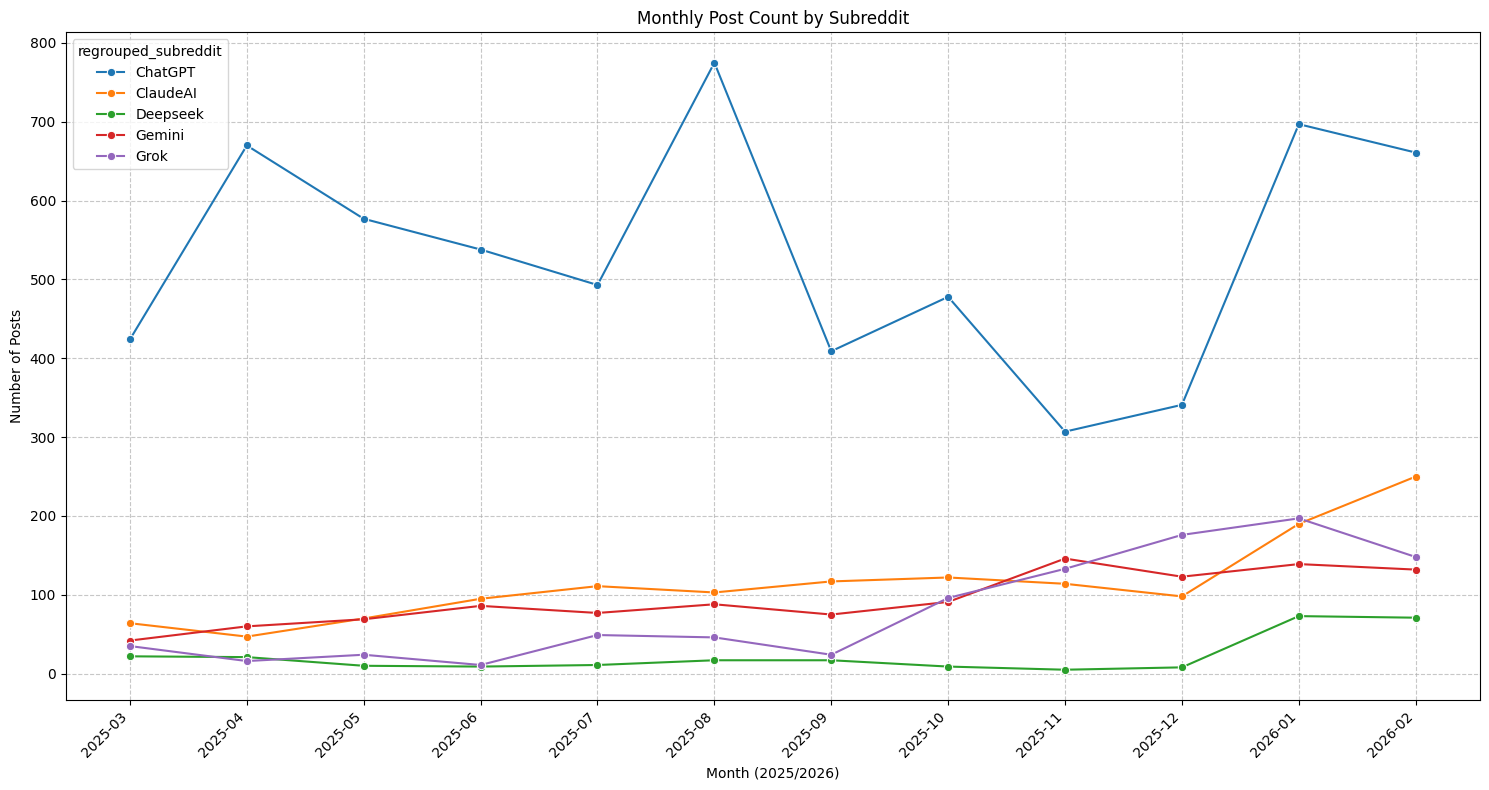

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the regrouping mapping
subreddit_mapping = {
    'ChatGPT': 'ChatGPT',
    'ChatGPTPro': 'ChatGPT',
    'OpenAI': 'ChatGPT',
    'ClaudeAI': 'ClaudeAI',
    'Anthropic': 'ClaudeAI',
    'GeminiAI': 'Gemini',
    'Bard': 'Gemini',
    'DeepSeek': 'Deepseek',
    'grok': 'Grok'
}

# Create a new column for regrouped subreddits in the melted DataFrame
df_melted_regrouped = df_melted.copy()
df_melted_regrouped['regrouped_subreddit'] = df_melted_regrouped['subreddit'].map(subreddit_mapping)

# Group by date_key and the new regrouped_subreddit, then sum the post_count
regrouped_monthly_posts = df_melted_regrouped.groupby(['date_key', 'regrouped_subreddit'])['post_count'].sum().reset_index()

# Set up the plot for regrouped subreddits
plt.figure(figsize=(15, 8))
sns.lineplot(data=regrouped_monthly_posts, x='date_key', y='post_count', hue='regrouped_subreddit', marker='o')

plt.title('Monthly Post Count by Subreddit')
plt.xlabel('Month (2025/2026)')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Group by the custom year, month, and subreddit to count posts
monthly_subreddit_comment_custom_year = comment.groupby(['analysis_year', 'month', 'date_key', 'subreddit']).size().unstack(fill_value=0)
monthly_subreddit_comment_custom_year = monthly_subreddit_comment_custom_year.reset_index()

# Melt the DataFrame to long format for easier plotting
df_melted = monthly_subreddit_comment_custom_year.melt(id_vars=['analysis_year', 'month', 'date_key'], var_name='subreddit', value_name='post_count')
display(df_melted.head())

,analysis_year,month,date_key,subreddit,post_count
0,2025,3,2025-03,Anthropic,2
1,2025,4,2025-04,Anthropic,0
2,2025,5,2025-05,Anthropic,1
3,2025,6,2025-06,Anthropic,4
4,2025,7,2025-07,Anthropic,10


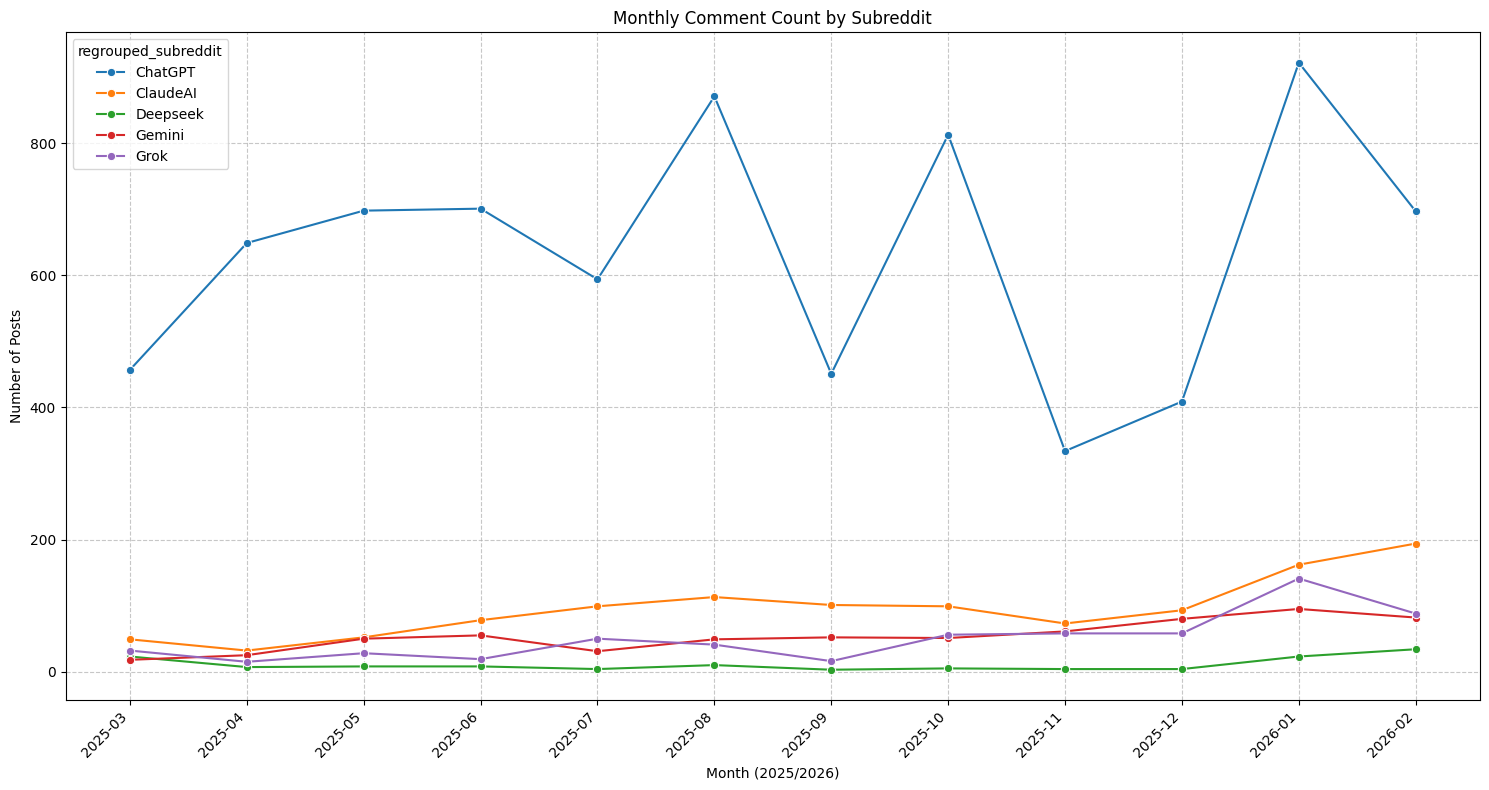

In [ ]:
# Define the regrouping mapping
subreddit_mapping = {
    'ChatGPT': 'ChatGPT',
    'ChatGPTPro': 'ChatGPT',
    'OpenAI': 'ChatGPT',
    'ClaudeAI': 'ClaudeAI',
    'Anthropic': 'ClaudeAI',
    'GeminiAI': 'Gemini',
    'Bard': 'Gemini',
    'DeepSeek': 'Deepseek',
    'grok': 'Grok'
}

# Create a new column for regrouped subreddits in the melted DataFrame
df_melted_regrouped = df_melted.copy()
df_melted_regrouped['regrouped_subreddit'] = df_melted_regrouped['subreddit'].map(subreddit_mapping)

# Group by date_key and the new regrouped_subreddit, then sum the post_count
regrouped_monthly_posts = df_melted_regrouped.groupby(['date_key', 'regrouped_subreddit'])['post_count'].sum().reset_index()

# Set up the plot for regrouped subreddits
plt.figure(figsize=(15, 8))
sns.lineplot(data=regrouped_monthly_posts, x='date_key', y='post_count', hue='regrouped_subreddit', marker='o')

plt.title('Monthly Comment Count by Subreddit')
plt.xlabel('Month (2025/2026)')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()